https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product?utm_source=chatgpt.com

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
DATASET = "archive (4)"

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    subset="validation"
)

Found 4305 images belonging to 2 classes.
Found 1076 images belonging to 2 classes.


In [4]:
model = models.Sequential([
    layers.Input(shape=(128,128,1)),
    layers.Conv2D(16, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.8088 - loss: 0.4576 - val_accuracy: 0.8039 - val_loss: 0.4521
Epoch 2/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step - accuracy: 0.8544 - loss: 0.3409 - val_accuracy: 0.7807 - val_loss: 0.3914
Epoch 3/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.8643 - loss: 0.3055 - val_accuracy: 0.7816 - val_loss: 0.4492
Epoch 4/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.8757 - loss: 0.2794 - val_accuracy: 0.8048 - val_loss: 0.3823
Epoch 5/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.8862 - loss: 0.2632 - val_accuracy: 0.7983 - val_loss: 0.3810


In [5]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

pred = (model.predict(val_data) > 0.5).astype(int)

print(classification_report(
    val_data.classes,
    pred,
    target_names=["Defective", "OK"]
))

68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.7937 - loss: 0.3904
Validation Accuracy: 0.7936803102493286
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step
              precision    recall  f1-score   support

   Defective       0.23      0.17      0.20       260
          OK       0.76      0.82      0.79       816

    accuracy                           0.67      1076
   macro avg       0.50      0.50      0.49      1076
weighted avg       0.63      0.67      0.65      1076



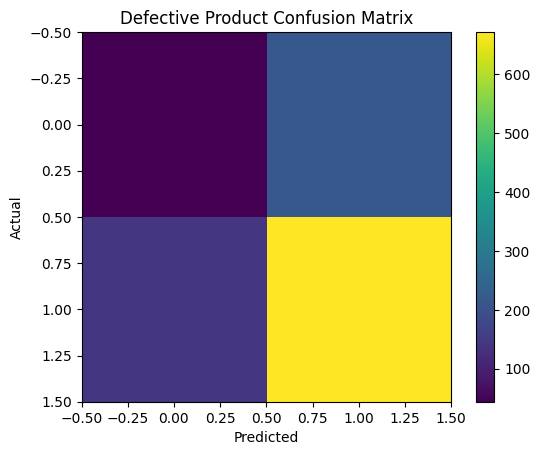

In [6]:
cm = confusion_matrix(
    val_data.classes,
    pred
)

plt.imshow(cm)
plt.title("Defective Product Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

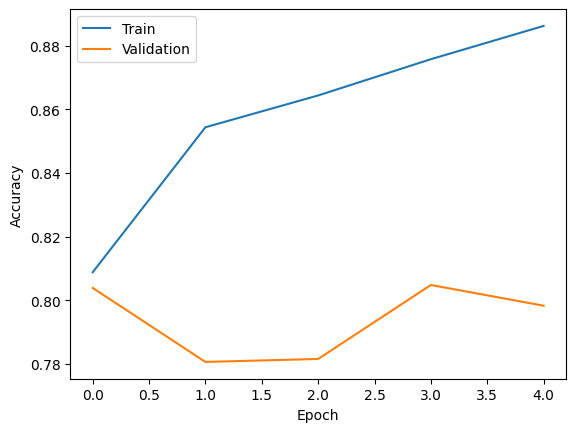

In [7]:
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()